# Лабораторная работа №3

In [ ]:
import numpy as np
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
import arviz

sns.set_style("ticks",{'axes.grid' : True})
sns.set_theme(rc={'figure.figsize':(8, 8)})

### Задание 1, вариант 2

Надо построить доверительный интервал для параметра $\tau=\mu_1 - \mu_2$ при условии $X$ ~ $N(\mu_1, \sigma_1^2)$, $Y$ ~ $N(\mu_2, \sigma_2^2)$, $\sigma_1^2=\sigma_2^2$ неизвестна.

$t = \sqrt{ \frac{mn(m + n - 2)}{m + n}} \cdot \frac{\bar{X} - \bar{Y} - \tau}{\sqrt{n \cdot \mathrm{Var}(X) + m \cdot \mathrm{Var}(Y)}}
= \frac{\bar{X} - \bar{Y} - \tau}{\sqrt{ \frac{n \cdot \mathrm{Var}(X) + m \cdot \mathrm{Var}(Y)}{ \frac{mn(m + n - 2)}{m + n} } }}
= \frac{\bar{X} - \bar{Y} - \tau}{\sqrt{ \left( \frac{(n - 1)s_X^2 + (m - 1)s_Y^2}{m + n - 2} \right) \cdot \left( \frac{m + n}{mn} \right) }}
= \frac{\bar{X} - \bar{Y} - \tau}{s_p \cdot \sqrt{ \frac{1}{n} + \frac{1}{m} }}$ - [формула для $t$-статистики](https://en.wikipedia.org/wiki/Student%27s_t-test#Equal_or_unequal_sample_sizes,_similar_variances_(%E2%81%A01/2%E2%81%A0_%3C_%E2%81%A0sX1/sX2%E2%81%A0_%3C_2) при равных значениях выборочной дисперсии

По ЦПТ $\frac{\bar{X}-\bar{Y}}{s_p\cdot \sqrt{\frac{1}{n}+\frac{1}{m}}} \rightarrow N(0, 1)$ $\Rightarrow$ $P(-c < \frac{\bar{X}-\bar{Y}}{s_p\cdot \sqrt{\frac{1}{n}+\frac{1}{m}}} < c) = 2\Phi(a) - 1 = 1 - \alpha$ $\Rightarrow$ $a=t_{1-\alpha/2, n  +m - 2}$

Тогда доверительный интервал имеет вид $(\bar{X}-\bar{Y})\pm\tau_{1-\alpha/2, n + m - 2} \cdot s_p \cdot \sqrt{\frac{1}{n}+\frac{1}{m}}$

Coverage (sample_size=5): 952 out of 1000 (95.20%)


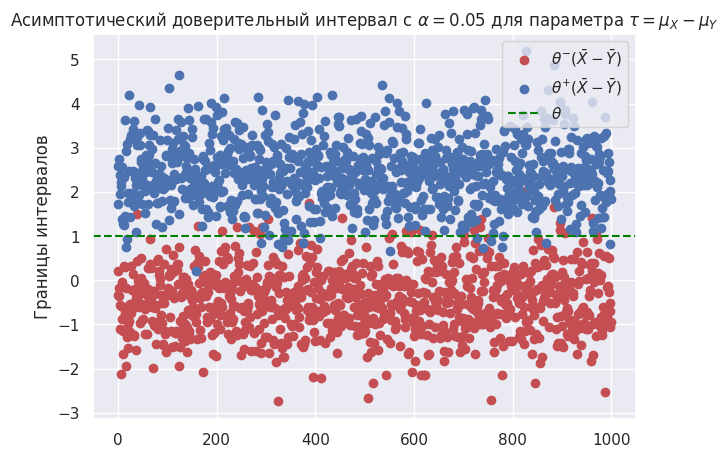

Coverage (sample_size=25): 950 out of 1000 (95.00%)


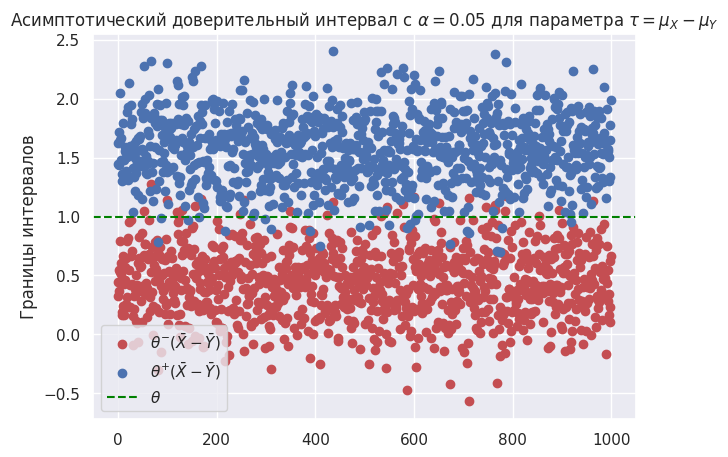

Coverage (sample_size=100): 967 out of 1000 (96.70%)


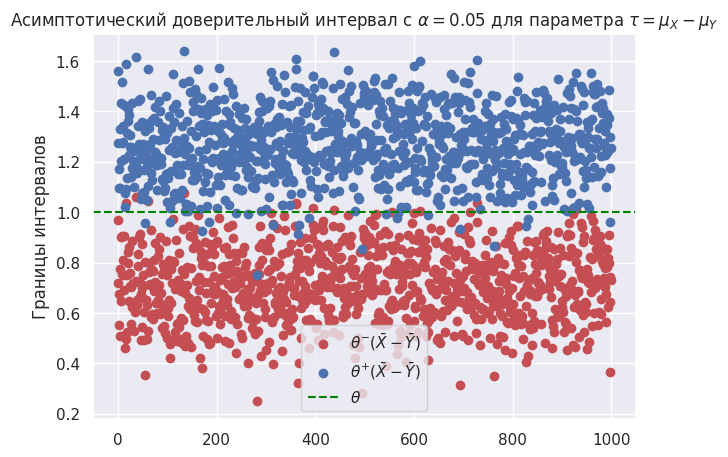

Coverage (sample_size=500): 945 out of 1000 (94.50%)


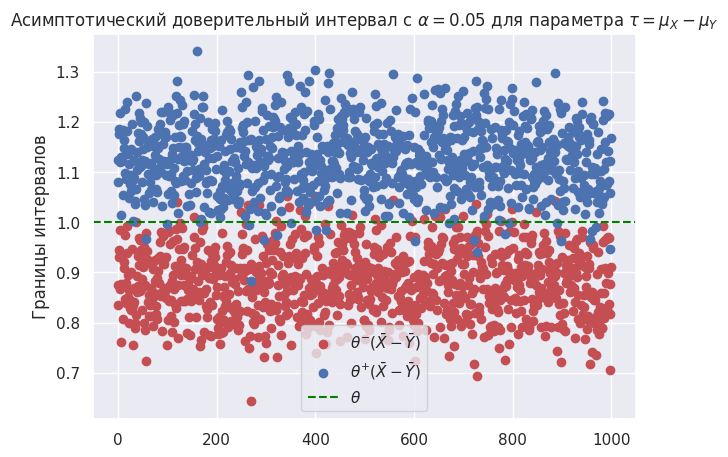

Coverage (sample_size=1000): 933 out of 1000 (93.30%)


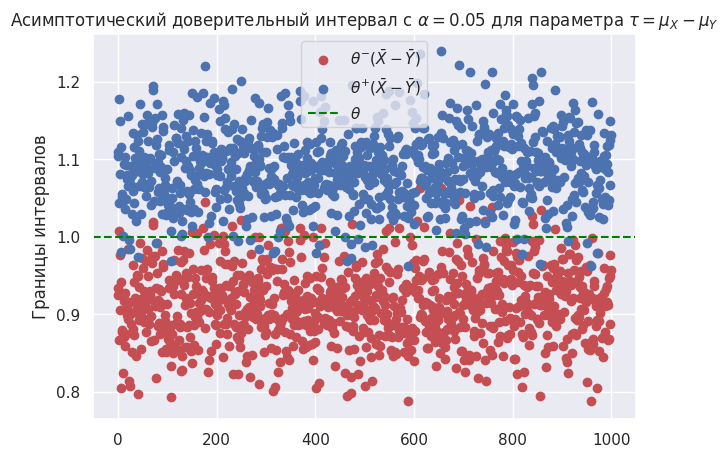

Coverage (sample_size=10000): 952 out of 1000 (95.20%)


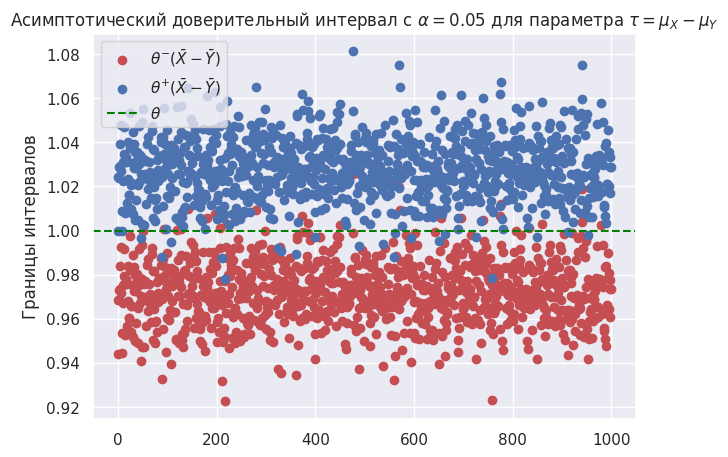

Coverage (sample_size=100000): 955 out of 1000 (95.50%)


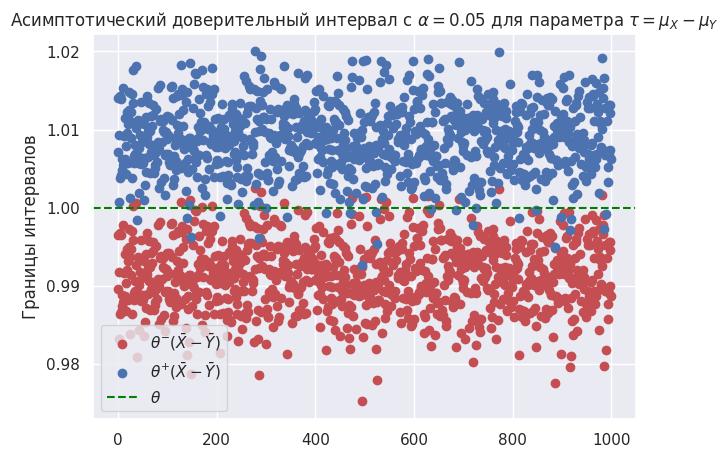

In [ ]:
sample_sizes = [5, 25, 100,500, 1000, 10000, 100000]
num_of_samples = 1000
alpha = 0.05  # уровень значимости

mu1 = 2
mu2 = 1
var1 = var2 = 1


for sample_size in sample_sizes:
    X = stats.norm.rvs(size=(num_of_samples, sample_size), loc=mu1, scale=np.sqrt(var1))
    Y = stats.norm.rvs(size=(num_of_samples, sample_size), loc=mu2, scale=np.sqrt(var2))

    n = m = sample_size
    meanX = X.mean(axis=1)
    meanY = Y.mean(axis=1)
    varX = X.var(ddof=0, axis=1)
    varY = Y.var(ddof=0, axis=1)
    Sp = np.sqrt((n * varX + m * varY) / (n + m - 2))
    tau = stats.t.ppf(1 - alpha / 2, df=n + m - 2)
    # границы доверительных интервалов
    ci_lower = (meanX - meanY) - tau * Sp * np.sqrt(1 / n + 1 / m)
    ci_upper = (meanX - meanY) + tau * Sp * np.sqrt(1 / n + 1 / m)
    count = ((mu1 - mu2 <= ci_upper) & (mu1 - mu2 >= ci_lower)).sum().item()
    coverage_percent = (count / num_of_samples) * 100
    print(f"Coverage ({sample_size=}): {count} out of {num_of_samples} ({coverage_percent:.2f}%)")

    # диаграммы с границами интервалов
    plt.figure(figsize=(7, 5))
    plt.scatter(range(num_of_samples), ci_lower, c="r", label=r"$\theta^{-}(\bar{X}-\bar{Y})$")
    plt.scatter(range(num_of_samples), ci_upper, c="b", label=r"$\theta^{+}(\bar{X}-\bar{Y})$")
    plt.axhline(mu1 - mu2, c="green", linestyle="dashed", label=r"$\theta$")
    plt.ylabel("Границы интервалов")
    plt.title("Асимптотический доверительный интервал с " + rf"$\alpha={alpha}$ " + "для параметра " + r"$\tau=\mu_X-\mu_Y$")
    plt.legend()
    plt.show()



При увеличении объема выборки доверительные интервалы становятся уже, а их покрытие истинного значения параметра $\tau=\mu_X-\mu_Y$​ стабилизируется и приближается к заявленному 95%. Благодаря увеличению объема выборки стандартная ошибка уменьшается, следовательно, уменьшается влияние случайных колебаний величины, что делает оценку более точной. Как видно по графикам, при увеличении размера выборки ширина доверительных интервалов уменьшается.

### Задание 2, вариант 1

По условию $X$ ~ $Exp(\lambda)$, надо построить доверительные интервалы уровня $1 - \alpha$ для медианы

По теореме об асимптотическом поведении средних членов вариационного ряда $\sqrt{n}\frac{X_{[np]}-q_p}{\sqrt{p(1-p)}}f(q_p) \rightarrow N(0, 1)$ $\Rightarrow$ $P(-c < \sqrt{n}\frac{X_{[np]}-q_p}{\sqrt{p(1-p)}}f(q_p) < c) = 2\Phi(c) - 1 \ge 1 - \alpha$ $\Rightarrow$ $c = \tau_{1 - \alpha/2, n - 1}$ и доверительный интервал имеет вид $X_{[np]}\pm q_p + c\frac{\sqrt{p(1-p)}}{\sqrt{n}f(q_p)}$

Coverage (sample_size=5): 974 out of 1000 (97.40%)


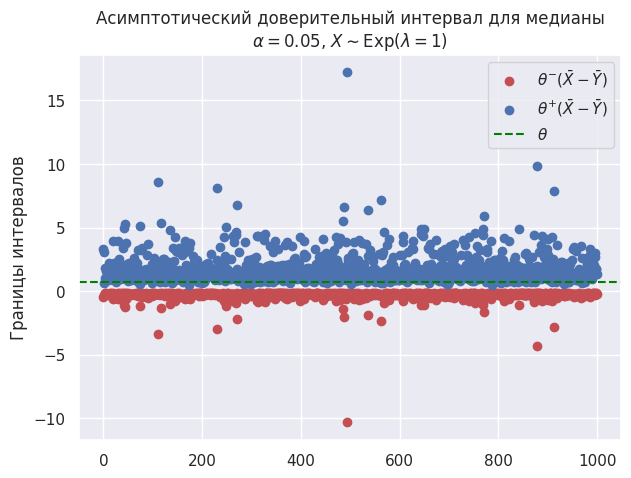

Coverage (sample_size=25): 970 out of 1000 (97.00%)


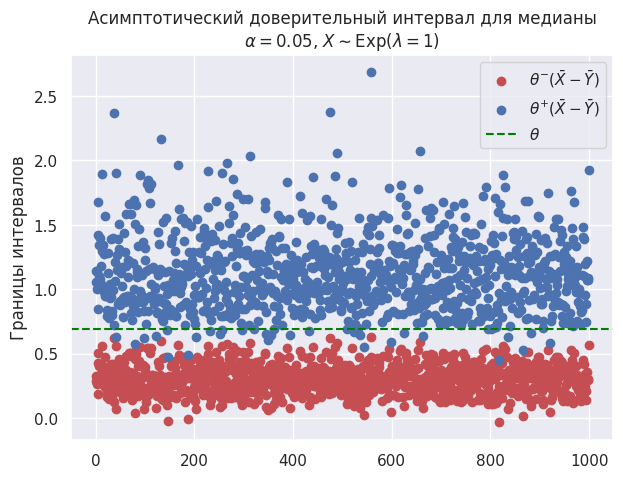

Coverage (sample_size=100): 960 out of 1000 (96.00%)


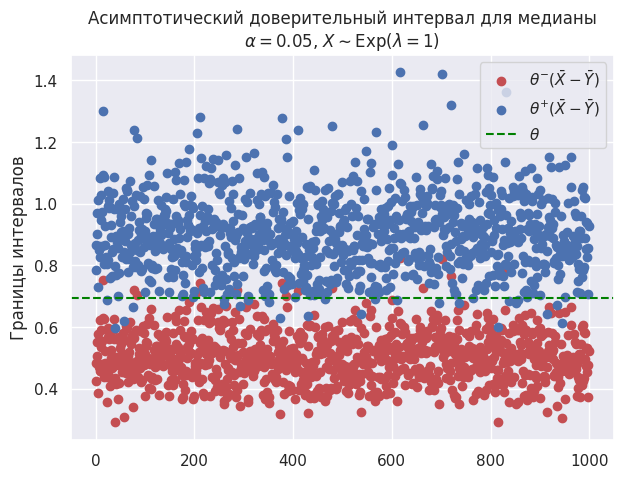

Coverage (sample_size=500): 949 out of 1000 (94.90%)


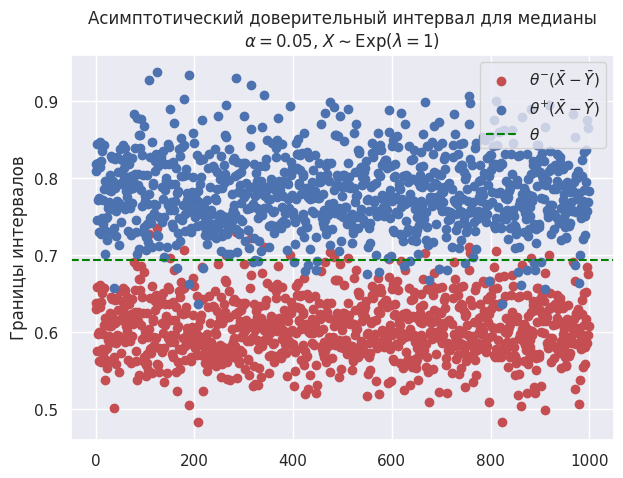

Coverage (sample_size=1000): 947 out of 1000 (94.70%)


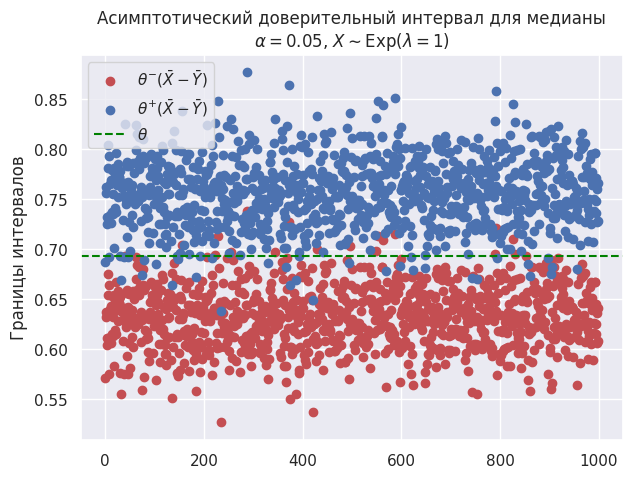

Coverage (sample_size=10000): 952 out of 1000 (95.20%)


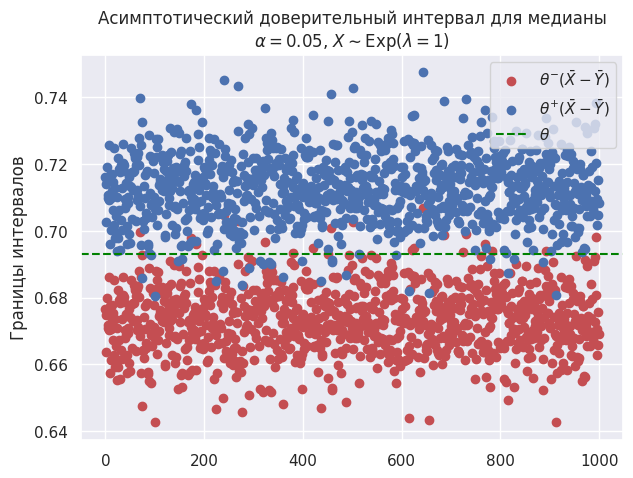

Coverage (sample_size=100000): 944 out of 1000 (94.40%)


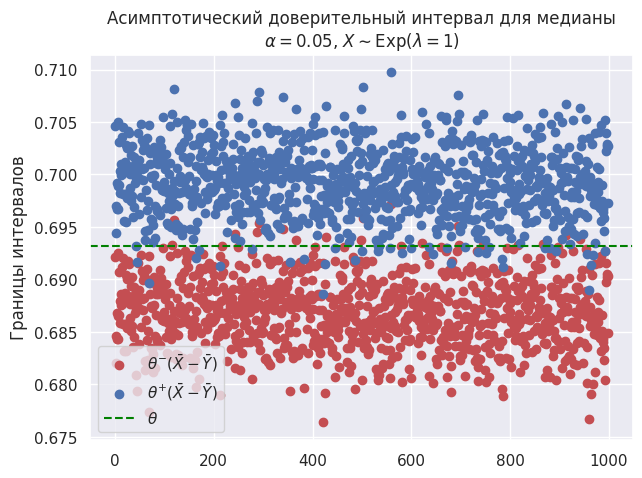

In [ ]:
sample_sizes = [5, 25, 100,500, 1000, 10000, 100000]
num_of_samples = 1000
alpha = 0.05  # уровень значимости

lambda1 = 1
distr = stats.expon(scale=1 / lambda1)
p = 1 / 2

median_true = np.log(2) / lambda1



for sample_size in sample_sizes:
    X = distr.rvs(size=(num_of_samples, sample_size))
    medians = np.median(X, axis=1)
    z = stats.norm.ppf(1 - alpha / 2)
    # границы доверительных интервалов
    ci_lower = medians - z * np.sqrt((p * (1 - p)) / (sample_size * distr.pdf(medians) ** 2))
    ci_upper = medians + z * np.sqrt((p * (1 - p)) / (sample_size * distr.pdf(medians) ** 2))
    count = ((median_true <= ci_upper) & (median_true >= ci_lower)).sum().item()
    coverage_percent = (count / num_of_samples) * 100
    print(f"Coverage ({sample_size=}): {count} out of {num_of_samples} ({coverage_percent:.2f}%)")

    # диаграммы с границами интервалов
    plt.figure(figsize=(7, 5))
    plt.scatter(range(num_of_samples), ci_lower, c="r", label=r"$\theta^{-}(\bar{X}-\bar{Y})$")
    plt.scatter(range(num_of_samples), ci_upper, c="b", label=r"$\theta^{+}(\bar{X}-\bar{Y})$")
    plt.axhline(median_true, c="green", linestyle="dashed", label=r"$\theta$")
    plt.ylabel("Границы интервалов")
    plt.title("Асимптотический доверительный интервал для медианы\n" + rf"$\alpha={alpha}$, $X \sim \mathrm{{Exp}}(\lambda=1)$")
    plt.legend()
    plt.show()



Аналогично первому заданию, при увеличении объема выборки асимптотические доверительные интервалы становятся уже, а их покрытие истинного значения параметра $median(X)$​ стабилизируется и приближается к заявленному 95%. Благодаря увеличению объема выборки стандартная ошибка уменьшается, следовательно, уменьшается влияние случайных колебаний величины, что делает оценку более точной. Как видно по графикам, при увеличении размера выборки ширина доверительных интервалов уменьшается.